# The Data

## Importing the data 

In [1]:
import kagglehub 
# Download latest version
path = kagglehub.dataset_download("utkarshx27/american-companies-bankruptcy-prediction-dataset")

print("Path to dataset files:", path)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/jonas/.cache/kagglehub/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset/versions/3


In [72]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
print(os.listdir(path))
original_dataset= pd.read_csv(path + "/american_bankruptcy.csv")
original_dataset.to_csv("forchat.csv",index=False)
n_firms = original_dataset["company_name"].nunique()
print(n_firms)





['american_bankruptcy.csv']
8971


## Sample construction

In [73]:
# Sort the dataset 
original_dataset= original_dataset.sort_values(["company_name", "year"])

# Makes a new column with "alive" as default
original_dataset["new_status"] = "alive"

mask_failed = original_dataset.groupby("company_name")["status_label"].transform(lambda x: (x == "failed").any())
mask_last = original_dataset["year"] == original_dataset.groupby("company_name")["year"].transform("max")

original_dataset.loc[mask_failed & mask_last, "new_status"] = "failed"

# Testing as C_20 is bankrupt 
original_dataset[original_dataset["company_name"] == "C_20"]



,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X10,X11,X12,X13,X14,X15,X16,X17,X18,new_status
239,C_20,failed,1999,264.225,3976.624,6.071,14.034,21.475,6.387,216.978,...,293.048,9.900,7.963,18.853,244.787,23.906,3995.477,257.027,3981.443,alive
240,C_20,failed,2000,420.349,6996.091,6.745,19.606,35.453,8.840,346.152,...,448.044,11.900,12.861,26.069,387.743,32.198,7022.160,403.731,7002.554,alive
241,C_20,failed,2001,199.305,4715.132,6.726,-5.784,10.004,-4.569,167.556,...,227.027,11.475,-12.510,2.110,168.971,27.081,4717.242,187.831,4723.026,alive
242,C_20,failed,2002,179.054,2307.357,5.565,7.787,6.591,1.452,141.852,...,202.120,11.475,2.222,15.960,147.762,27.985,2323.317,162.020,2315.530,alive
243,C_20,failed,2003,185.651,1700.737,5.665,14.893,6.874,3.102,140.425,...,210.261,11.475,9.228,21.192,152.665,30.117,1721.929,168.029,1707.036,alive
244,C_20,failed,2004,209.339,2041.384,6.572,20.537,11.372,8.608,169.680,...,238.854,11.475,13.965,28.404,173.550,37.460,2069.788,189.279,2049.251,alive
245,C_20,failed,2005,270.450,2329.094,7.060,26.071,11.692,17.641,232.355,...,312.662,11.475,19.011,35.739,231.129,53.541,2364.833,247.006,2338.762,alive
246,C_20,failed,2006,241.790,2213.615,9.485,24.452,7.950,10.483,208.633,...,289.287,3.000,14.967,32.988,206.582,62.253,2246.603,214.919,2222.151,alive
247,C_20,failed,2007,311.893,2602.035,11.384,23.213,14.776,17.056,269.652,...,357.075,0.000,11.829,34.187,261.321,77.327,2636.222,267.633,2613.009,alive
248,C_20,failed,2008,169.366,4148.106,13.373,1.899,14.207,-5.572,123.030,...,210.926,0.000,-11.474,11.566,127.807,69.646,4159.672,129.165,4157.773,alive


### Creating binary target variable 

In [ ]:
original_dataset["bankruptcy"] = (original_dataset["new_status"] == "failed").astype(int)
original_dataset[original_dataset["bankruptcy"] == 1].sort_index()

#original_dataset.drop(columns="status_label", inplace=True)
original_dataset.drop(columns="new_status", inplace=True)
original_dataset.info()


<class 'pandas.core.frame.DataFrame'>
Index: 78682 entries, 0 to 11925
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company_name  78682 non-null  object 
 1   year          78682 non-null  int64  
 2   X1            78682 non-null  float64
 3   X2            78682 non-null  float64
 4   X3            78682 non-null  float64
 5   X4            78682 non-null  float64
 6   X5            78682 non-null  float64
 7   X6            78682 non-null  float64
 8   X7            78682 non-null  float64
 9   X8            78682 non-null  float64
 10  X9            78682 non-null  float64
 11  X10           78682 non-null  float64
 12  X11           78682 non-null  float64
 13  X12           78682 non-null  float64
 14  X13           78682 non-null  float64
 15  X14           78682 non-null  float64
 16  X15           78682 non-null  float64
 17  X16           78682 non-null  float64
 18  X17           78682 non-null  f

### Creating regimes 


In [400]:
df_model_1= original_dataset.copy()

df_model_1["regime"] = "outside"

df_model_1.loc[(df_model_1["year"] >= 2002) & (df_model_1["year"] <= 2006), "regime"] = "pre_crisis"
df_model_1 .loc[(df_model_1["year"] >= 2007) & (df_model_1["year"] <= 2009), "regime"] = "crisis"
df_model_1.loc[(df_model_1["year"] >= 2010) & (df_model_1["year"] <= 2017), "regime"] = "post_crisis"

df_model_1["regime"].value_counts()

# The three regimes 
df_filtered = df_model_1[df_model_1["regime"].isin(["pre_crisis", "crisis", "post_crisis"])]

unique_values = df_filtered["company_name"].nunique()
total_observations= df_filtered.shape[0]

# OUTSIDE 
df_filtered_outside = df_model_1[df_model_1["regime"].isin(["outside"])]

total_observations_outside= df_filtered_outside.shape[0]

summary = pd.DataFrame({
    "Total observations": [total_observations, total_observations_outside,total_observations + total_observations_outside],
    "Unique values": [unique_values,"",""]

},index=["Pre, Crisis, Post","Outside", "Total"])

summary



,Total observations,Unique values
"Pre, Crisis, Post",60528,7605
Outside,18154,
Total,78682,


## Feature creation 

In [401]:

# renaming the features #
df_filtered.rename(columns={
    'X1':'current_assets',
    'X2':'cost_of_goods_sold',
    'X3':'depreciation_and_amortization',
    'X4':'ebitda',
    'X5':'inventory',
    'X6':'net_income',
    'X7':'total_receivables',
    'X8':'market_value',
    'X9':'net_sales',
    'X10':'total_assets',
    'X11':'total_long_term_debt',
    'X12':'ebit',
    'X13':'gross_profit',
    'X14':'total_current_liabilities',
    'X15':'retained_earnings',
    'X16':'total_revenue',
    'X17':'total_liabilities',
    'X18':'total_operating_expenses'}, inplace = True)

# df_filtered.info

# Creating financial ratios 


df_financial_features = df_filtered.copy()

# --- Liquidity ---
df_financial_features["current_ratio"] = df_financial_features["current_assets"] / df_financial_features["total_current_liabilities"]
df_financial_features["working_capital_ratio"] = (df_financial_features["current_assets"] - df_financial_features["total_current_liabilities"]) / df_financial_features["total_assets"]
df_financial_features["receivables_liquidity_ratio"] = df_financial_features["total_receivables"] / df_financial_features["total_current_liabilities"]

# --- Leverage ---
df_financial_features["debt_ratio"] = df_financial_features["total_liabilities"] / df_financial_features["total_assets"]
df_financial_features["long_term_debt_ratio"] = df_financial_features["total_long_term_debt"] / df_financial_features["total_assets"]
df_financial_features["debt_to_sales"] = df_financial_features["total_liabilities"] / df_financial_features["net_sales"]
df_financial_features["debt_to_revenue"] = df_financial_features["total_liabilities"] / df_financial_features["total_revenue"]
df_financial_features["current_liabilities_ratio"] = df_financial_features["total_current_liabilities"] / df_financial_features["total_assets"]
df_financial_features["market_to_liability"] = df_financial_features["market_value"] / df_financial_features["total_liabilities"]

# --- Profitability ---
df_financial_features["roa_net_income"] = df_financial_features["net_income"] / df_financial_features["total_assets"]
df_financial_features["profit_margin"] = df_financial_features["net_income"] / df_financial_features["net_sales"]
df_financial_features["ebit_margin"] = df_financial_features["ebit"] / df_financial_features["net_sales"]
df_financial_features["gross_margin"] = df_financial_features["gross_profit"] / df_financial_features["net_sales"]

# --- Turnover ---
df_financial_features["asset_turnover"] = df_financial_features["net_sales"] / df_financial_features["total_assets"]
df_financial_features["receivables_turnover"] = df_financial_features["net_sales"] / df_financial_features["total_receivables"]
df_financial_features["inventory_turnover"] = df_financial_features["cost_of_goods_sold"] / df_financial_features["inventory"]
df_financial_features["operating_expense_ratio"] = df_financial_features["total_operating_expenses"] / df_financial_features["net_sales"]

# --- Cash flow / operating ---
df_financial_features["ebitda_to_assets"] = df_financial_features["ebitda"] / df_financial_features["total_assets"]
df_financial_features["ebitda_to_liabilities"] = df_financial_features["ebitda"] / df_financial_features["total_liabilities"]
df_financial_features["ebitda_to_sales"] = df_financial_features["ebitda"] / df_financial_features["net_sales"]
df_financial_features["operating_expense_burden"] = df_financial_features["total_operating_expenses"] / df_financial_features["total_assets"]

# --- Size ---
df_financial_features["log_total_assets"] = np.log(df_financial_features["total_assets"])
df_financial_features["log_net_sales"] = np.log(df_financial_features["net_sales"])
df_financial_features["log_market_value"] = np.log(df_financial_features["market_value"])

# --- Other ---
df_financial_features["market_to_assets"] = df_financial_features["market_value"] / df_financial_features["total_assets"]
df_financial_features["retained_earnings_to_assets"] = df_financial_features["retained_earnings"] / df_financial_features["total_assets"]

df_financial_features["company_name"].value_counts()
df_financial_features.info()






/var/folders/62/2zl_g_593t142qtwbk33680r0000gn/T/ipykernel_1194/702074256.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.rename(columns={
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<class 'pandas.core.frame.DataFrame'>
Index: 60528 entries, 3 to 11924
Data columns (total 48 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   company_name                   60528 non-null  object 
 1   year                           60528 non-null  int64  
 2   current_assets                 60528 non-null  float64
 3   cost_of_goods_sold             60528 non-null  float64
 4   depreciation_and_amortization  60528 non-null  float64
 5   ebitda                         60528 non-null  float64
 6   inventory                      60528 non-null  float64
 7   net_income                     60528 non-null  float64
 8   total_receivables              60528 non-null  float64
 9   market_value                   60528 non-null  float64
 10  net_sales                      60528 non-null  float64
 11  total_assets                   60528 non-null  float64
 12  total_long_term_debt           60528 non-null  floa

## Distribution, Missing values  and outliers 

### Dropping level variables and observations where regime="outside" Dataset ready for inspection 

In [402]:
df_final_dataset = df_financial_features.copy()

df_final_dataset.drop(columns={
    'current_assets',
    'cost_of_goods_sold',
    'depreciation_and_amortization',
    'ebitda',
    'inventory',
    'net_income',
    'total_receivables',
    'market_value',
    'net_sales',
    'total_assets',
    'total_long_term_debt',
    'ebit',
    'gross_profit',
    'total_current_liabilities',
    'retained_earnings',
    'total_revenue',
    'total_liabilities',
    'total_operating_expenses'}, inplace = True)



df_final_dataset.info()



<class 'pandas.core.frame.DataFrame'>
Index: 60528 entries, 3 to 11924
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   company_name                 60528 non-null  object 
 1   year                         60528 non-null  int64  
 2   bankruptcy                   60528 non-null  int64  
 3   regime                       60528 non-null  object 
 4   current_ratio                60528 non-null  float64
 5   working_capital_ratio        60528 non-null  float64
 6   receivables_liquidity_ratio  60528 non-null  float64
 7   debt_ratio                   60528 non-null  float64
 8   long_term_debt_ratio         60528 non-null  float64
 9   debt_to_sales                60528 non-null  float64
 10  debt_to_revenue              60528 non-null  float64
 11  current_liabilities_ratio    60528 non-null  float64
 12  market_to_liability          60528 non-null  float64
 13  roa_net_income       

### Missing values

#### Missing values detection 

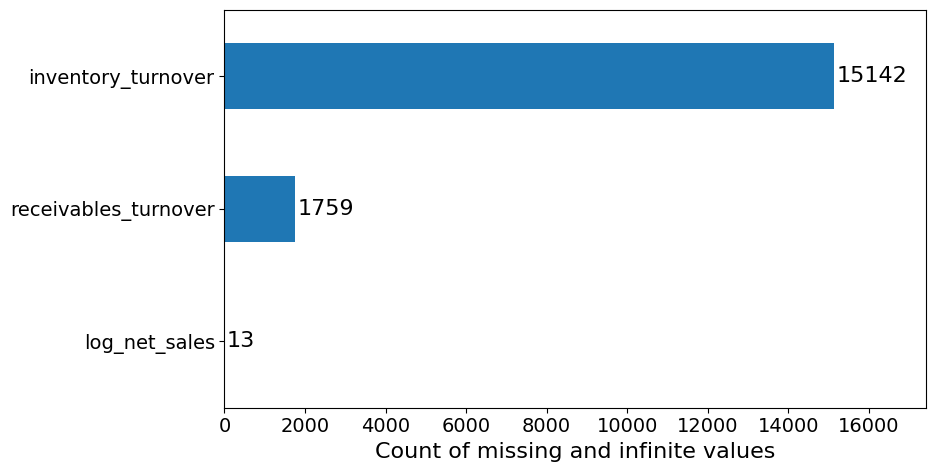

missing valies
 company_name                     0
year                             0
bankruptcy                       0
regime                           0
current_ratio                    0
working_capital_ratio            0
receivables_liquidity_ratio      0
debt_ratio                       0
long_term_debt_ratio             0
debt_to_sales                    0
debt_to_revenue                  0
current_liabilities_ratio        0
market_to_liability              0
roa_net_income                   0
profit_margin                    0
ebit_margin                      0
gross_margin                     0
asset_turnover                   0
receivables_turnover             0
inventory_turnover             239
operating_expense_ratio          0
ebitda_to_assets                 0
ebitda_to_liabilities            0
ebitda_to_sales                  0
operating_expense_burden         0
log_total_assets                 0
log_net_sales                   13
log_market_value                 0
mark

In [403]:
# Count infinite values for each numeric variable
inf_values = np.isinf(
    df_final_dataset.select_dtypes(include=[np.number])
).sum()

# Reindex so non-numeric variables also appear with 0 infinite values
inf_values = inf_values.reindex(df_final_dataset.columns, fill_value=0)

# Counting missing values 
Missing_values= (df_final_dataset.isna().sum())
total_missingness = inf_values + Missing_values


problem_values = total_missingness[total_missingness > 0].sort_values()

ax = problem_values.plot(kind="barh", figsize=(10, 5))

ax.set_xlabel("Count of missing and infinite values")


# Add exact values at end of bars
for i, value in enumerate(problem_values):
    ax.text(value + 50, i, str(int(value)), va="center")

plt.tight_layout()
ax.set_xlim(0, problem_values.max() * 1.15)
plt.savefig("missing_values.pdf", bbox_inches="tight")
plt.show()

print("missing valies\n",Missing_values)
print("inf values:\n", inf_values)

##### Elaboration on missing values 

In [ ]:
#Inf values
np.isinf(df_final_dataset["inventory_turnover"]).sum()
# missing values 
df_final_dataset["inventory_turnover"].isna().sum()
df_final_dataset["log_net_sales"].isna().sum()


#Counting on the specified regimes 
df_regime_specific = df_filtered[df_filtered["regime"] != "outside"].copy()



print("net_sales < 0:", (df_regime_specific["net_sales"] < 0).sum())
print("total_receivables =  0:", (df_regime_specific["total_receivables"] == 0).sum())
print("inventory == 0:", (df_regime_specific["inventory"] == 0).sum())
print(
    "inventory == 0 and cost_of_goods_sold == 0:",
    ((df_regime_specific["inventory"] == 0) & (df_regime_specific["cost_of_goods_sold"] == 0)).sum()
)
df_regime_specific.loc[df["net_sales"] <= 0, ["net_sales", "bankruptcy"]]

df_regime_specific.shape

net_sales < 0: 13
total_receivables =  0: 1759
inventory == 0: 15142
inventory == 0 and cost_of_goods_sold == 0: 239


(60528, 22)

#### creating binary variable for inventory=0 and dropping inventory turnover

In [418]:


df_final_dataset["zero_inventory"] = (
    df_final_dataset["inventory_turnover"].isna() |
    np.isinf(df_final_dataset["inventory_turnover"])
).astype(int)

print(df_final_dataset["zero_inventory"].value_counts())


#dropping the inventory_turnover
df_final_dataset = df_final_dataset.drop(columns=["inventory_turnover"])
df_final_dataset.info()



zero_inventory
0    45386
1    15142
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 60528 entries, 3 to 11924
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   company_name                 60528 non-null  object 
 1   year                         60528 non-null  int64  
 2   bankruptcy                   60528 non-null  int64  
 3   regime                       60528 non-null  object 
 4   current_ratio                60528 non-null  float64
 5   working_capital_ratio        60528 non-null  float64
 6   receivables_liquidity_ratio  60528 non-null  float64
 7   debt_ratio                   60528 non-null  float64
 8   long_term_debt_ratio         60528 non-null  float64
 9   debt_to_sales                60528 non-null  float64
 10  debt_to_revenue              60528 non-null  float64
 11  current_liabilities_ratio    60528 non-null  float64
 12  market_to_liabil

#### Creating binary indicator for account_receivables = 0 

In [419]:
df_final_dataset["zero_accounts_receivables"] = (
    np.isinf(df_final_dataset["receivables_turnover"])
).astype(int)

print(df_final_dataset["zero_accounts_receivables"].value_counts())





zero_accounts_receivables
0    58769
1     1759
Name: count, dtype: int64


#### Imputing receivables turnover with median

In [420]:
# Replace infinite values with NaN, as .median ignores them
df_final_dataset["receivables_turnover"] = df_final_dataset["receivables_turnover"].replace(
    [np.inf, -np.inf], 
    np.nan)

print(df_final_dataset.isna().sum())


# Calculate the median using only finite/non-missing values
receivables_turnover_median = df_final_dataset["receivables_turnover"].median() 


# Impute missing values with the median
df_final_dataset["receivables_turnover"] = df_final_dataset["receivables_turnover"].fillna(
    receivables_turnover_median
)


# Validation checks
print(df_final_dataset["zero_accounts_receivables"].value_counts())

print("Remaining infinite values:",
      np.isinf(df_final_dataset["receivables_turnover"]).sum())

print("Remaining missing values:",
      df_final_dataset["receivables_turnover"].isna().sum())

print("Median used for imputation:", receivables_turnover_median)

print(df_final_dataset["receivables_turnover"].head(400))


company_name                      0
year                              0
bankruptcy                        0
regime                            0
current_ratio                     0
working_capital_ratio             0
receivables_liquidity_ratio       0
debt_ratio                        0
long_term_debt_ratio              0
debt_to_sales                     0
debt_to_revenue                   0
current_liabilities_ratio         0
market_to_liability               0
roa_net_income                    0
profit_margin                     0
ebit_margin                       0
gross_margin                      0
asset_turnover                    0
receivables_turnover           1759
operating_expense_ratio           0
ebitda_to_assets                  0
ebitda_to_liabilities             0
ebitda_to_sales                   0
operating_expense_burden          0
log_total_assets                  0
log_net_sales                    13
log_market_value                  0
market_to_assets            

#### Dropping observations where log sales is missing. 

In [421]:
df_final_dataset = df_final_dataset.dropna(subset=["log_net_sales"])

df_final_dataset["log_net_sales"].isna().sum()
df_final_dataset.shape
df_final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60515 entries, 3 to 11924
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   company_name                 60515 non-null  object 
 1   year                         60515 non-null  int64  
 2   bankruptcy                   60515 non-null  int64  
 3   regime                       60515 non-null  object 
 4   current_ratio                60515 non-null  float64
 5   working_capital_ratio        60515 non-null  float64
 6   receivables_liquidity_ratio  60515 non-null  float64
 7   debt_ratio                   60515 non-null  float64
 8   long_term_debt_ratio         60515 non-null  float64
 9   debt_to_sales                60515 non-null  float64
 10  debt_to_revenue              60515 non-null  float64
 11  current_liabilities_ratio    60515 non-null  float64
 12  market_to_liability          60515 non-null  float64
 13  roa_net_income       

## Outliers of the features 

#### Winzorisation of the data

In [422]:
import numpy as np
import matplotlib.pyplot as plt
import math

# --------------------------------------------------
# 1. Select continuous features
# --------------------------------------------------
continuous_features = df_final_dataset.drop(
    columns=[
        "company_name", "regime", "year", "bankruptcy",
        "zero_inventory", "zero_accounts_receivables"
    ],
    errors="ignore"
)

continuous_features = continuous_features.select_dtypes(include=[np.number])
feature_cols = continuous_features.columns.tolist()

# --------------------------------------------------
# 2. Create winsorized dataset
# --------------------------------------------------
df_winsorization = df_final_dataset.copy()

for col in feature_cols:
    p01 = df_winsorization[col].quantile(0.01)
    p99 = df_winsorization[col].quantile(0.99)
    df_winsorization[col] = np.where(df_winsorization[col] < p01, p01, df_winsorization[col])
    df_winsorization[col] = np.where(df_winsorization[col] > p99, p99, df_winsorization[col])
    print(f"{col}: min={df_winsorization[col].min():.2f}, max={df_winsorization[col].max():.2f}")




current_ratio: min=0.03, max=18.56
working_capital_ratio: min=-10.64, max=0.87
receivables_liquidity_ratio: min=0.00, max=2.61
debt_ratio: min=0.05, max=13.66
long_term_debt_ratio: min=0.00, max=1.48
debt_to_sales: min=0.08, max=110.79
debt_to_revenue: min=0.08, max=110.79
current_liabilities_ratio: min=0.03, max=11.37
market_to_liability: min=0.03, max=84.90
roa_net_income: min=-9.90, max=0.38
profit_margin: min=-135.80, max=0.56
ebit_margin: min=-114.59, max=0.45
gross_margin: min=-61.19, max=0.95
asset_turnover: min=0.01, max=4.94
receivables_turnover: min=0.74, max=204.45
operating_expense_ratio: min=0.37, max=111.89
ebitda_to_assets: min=-6.80, max=0.43
ebitda_to_liabilities: min=-6.11, max=2.41
ebitda_to_sales: min=-110.89, max=0.63
operating_expense_burden: min=0.07, max=10.25
log_total_assets: min=-1.72, max=10.80
log_net_sales: min=-3.41, max=10.64
log_market_value: min=-0.52, max=11.03
market_to_assets: min=0.04, max=50.54
retained_earnings_to_assets: min=-111.96, max=0.97


#### Appendix: same x-axis scale before and after winsorization

In [423]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import math

# Number of variables per page
vars_per_page = 6

output_pdf = "appendix_boxplots_before_after_same_scale_multipage.pdf"

with PdfPages(output_pdf) as pdf:
    for start in range(0, len(feature_cols), vars_per_page):
        subset_cols = feature_cols[start:start + vars_per_page]

        n_vars = len(subset_cols)

        fig, axes = plt.subplots(n_vars, 2, figsize=(12, 2.5 * n_vars))

        if n_vars == 1:
            axes = np.array([axes])

        for i, col in enumerate(subset_cols):
            data_before = df_final_dataset[col]
            data_after = df_winsorization[col]

            combined_min = min(data_before.min(), data_after.min())
            combined_max = max(data_before.max(), data_after.max())

            margin = 0.05 * (combined_max - combined_min)

            axes[i, 0].boxplot(data_before, vert=False)
            axes[i, 0].set_title(f"{col} - Before", fontsize=9)
            axes[i, 0].set_yticks([])
            axes[i, 0].set_xlim(combined_min - margin, combined_max + margin)

            axes[i, 1].boxplot(data_after, vert=False)
            axes[i, 1].set_title(f"{col} - After", fontsize=9)
            axes[i, 1].set_yticks([])
            axes[i, 1].set_xlim(combined_min - margin, combined_max + margin)

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

#### Selected variables: same x-axis for the after-winsorization plots

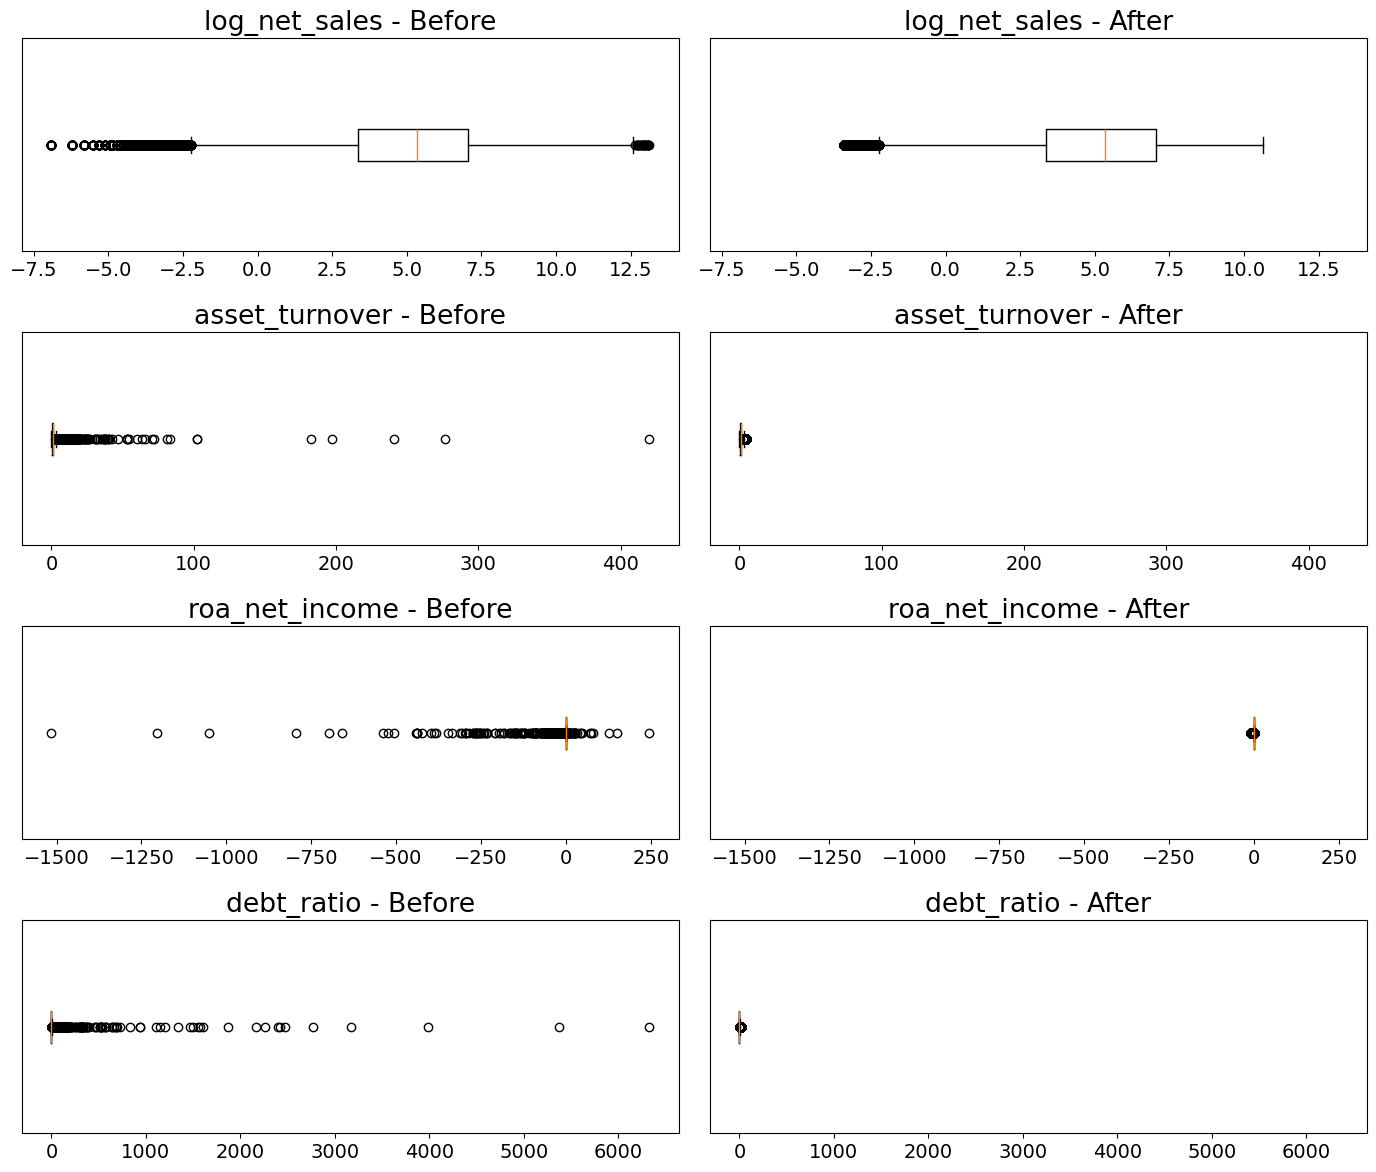

In [424]:
import numpy as np
import matplotlib.pyplot as plt

df_winsorization_selected= df_winsorization[["log_net_sales", "asset_turnover", "roa_net_income","debt_ratio"]]
# --------------------------------------------------
# 3. Plot selected variables with same x-axis scale
# --------------------------------------------------

selected_features = [
    "log_net_sales",
    "asset_turnover",
    "roa_net_income",
    "debt_ratio"
]
n_vars = len(selected_features)

fig, axes = plt.subplots(n_vars, 2, figsize=(14, 3 * n_vars))

# Ensures axes is 2-dimensional if only one variable is selected
if n_vars == 1:
    axes = np.array([axes])

for i, col in enumerate(selected_features):
    data_before = df_final_dataset[col]
    data_after = df_winsorization[col]

    # Common x-axis range based on before and after values
    combined_min = min(data_before.min(), data_after.min())
    combined_max = max(data_before.max(), data_after.max())

    # Add small margin so points are not placed directly on the border
    margin = 0.05 * (combined_max - combined_min)

    # Before winsorization
    axes[i, 0].boxplot(data_before, vert=False)
    axes[i, 0].set_title(f"{col} - Before")
    axes[i, 0].set_yticks([])
    axes[i, 0].set_xlim(combined_min - margin, combined_max + margin)

    # After winsorization
    axes[i, 1].boxplot(data_after, vert=False)
    axes[i, 1].set_title(f"{col} - After")
    axes[i, 1].set_yticks([])
    axes[i, 1].set_xlim(combined_min - margin, combined_max + margin)

plt.tight_layout()
plt.savefig("selected_boxplots_before_after_same_scale.pdf", bbox_inches="tight")
plt.show()

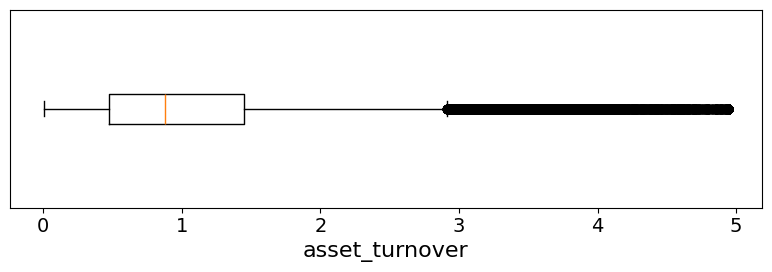

In [426]:
## Taking asset turnover as an example 
# Create single boxplot
plt.figure(figsize=(8, 3))
plt.boxplot(df_winsorization["asset_turnover"], vert=False)


plt.xlabel("asset_turnover")
plt.yticks([])

plt.tight_layout()
plt.savefig("asset_turnover_after_winsorization_boxplot.pdf", bbox_inches="tight")
plt.show()

#### Numerical inspection of OUTLIERS IQRS 
 

In [427]:
print("Before Winsorization:\n")
for col in df_final_dataset[feature_cols]:
    Q_1= df_final_dataset[col].quantile(0.25) # will return a single number. the quantile takes all the observations in col and take the first quantile
    Q_3= df_final_dataset[col].quantile(0.75) # same for this 
    IQR= Q_3 - Q_1 # single number 
    lower_bound= Q_1 - 1.5*IQR
    Upper_bound= Q_3 + 1.5*IQR
    outliers = ((df_final_dataset[col]< lower_bound) | (df_final_dataset[col]> Upper_bound)).sum() # Here, box_plt[col] contains all the observations inside X1 which is compared to the bounderies.
    #  | means or, so only one of the expressions have to be true for the sum to count it as true. In this way it capture every obs < lower_bound and > upper_ bound
    # In this way, if the value in col is below lower_bound = true sum counts 1
    # If it is below lower_bound but above the upper bound it is true and the sum counts it
    # If it is inbetween both are statements are false and the .sum() does not count it
    # The .sum then count the true values, hence either below lower or above upper limit i.e. outliers 
    print(f"{col}: {outliers} outliers by IQR rule")


print("After Winsorization:\n")
# AFTER winzoirization 
for col in df_winsorization[feature_cols]:
    Q_1= df_winsorization[col].quantile(0.25) # will return a single number. the quantile takes all the observations in col and take the first quantile
    Q_3= df_winsorization[col].quantile(0.75) # same for this 
    IQR= Q_3 - Q_1 # single number 
    lower_bound= Q_1 - 1.5*IQR
    Upper_bound= Q_3 + 1.5*IQR
    outliers = ((df_winsorization[col]< lower_bound) | (df_winsorization[col]> Upper_bound)).sum() # Here, box_plt[col] contains all the observations inside X1 which is compared to the bounderies.
    #  | means or, so only one of the expressions have to be true for the sum to count it as true. In this way it capture every obs < lower_bound and > upper_ bound
    # In this way, if the value in col is below lower_bound = true sum counts 1
    # If it is below lower_bound but above the upper bound it is true and the sum counts it
    # If it is inbetween both are statements are false and the .sum() does not count it
    # The .sum then count the true values, hence either below lower or above upper limit i.e. outliers 
    print(f"{col}: {outliers} outliers by IQR rule")


Before Winsorization:

current_ratio: 5076 outliers by IQR rule
working_capital_ratio: 3193 outliers by IQR rule
receivables_liquidity_ratio: 1751 outliers by IQR rule
debt_ratio: 4090 outliers by IQR rule
long_term_debt_ratio: 2337 outliers by IQR rule
debt_to_sales: 7226 outliers by IQR rule
debt_to_revenue: 7226 outliers by IQR rule
current_liabilities_ratio: 5160 outliers by IQR rule
market_to_liability: 6695 outliers by IQR rule
roa_net_income: 8690 outliers by IQR rule
profit_margin: 10911 outliers by IQR rule
ebit_margin: 10522 outliers by IQR rule
gross_margin: 4014 outliers by IQR rule
asset_turnover: 2956 outliers by IQR rule
receivables_turnover: 7933 outliers by IQR rule
operating_expense_ratio: 11002 outliers by IQR rule
ebitda_to_assets: 8340 outliers by IQR rule
ebitda_to_liabilities: 10503 outliers by IQR rule
ebitda_to_sales: 11002 outliers by IQR rule
operating_expense_burden: 4067 outliers by IQR rule
log_total_assets: 663 outliers by IQR rule
log_net_sales: 1293 out

#### Distributions 

##### All distribtuion PLOTS 

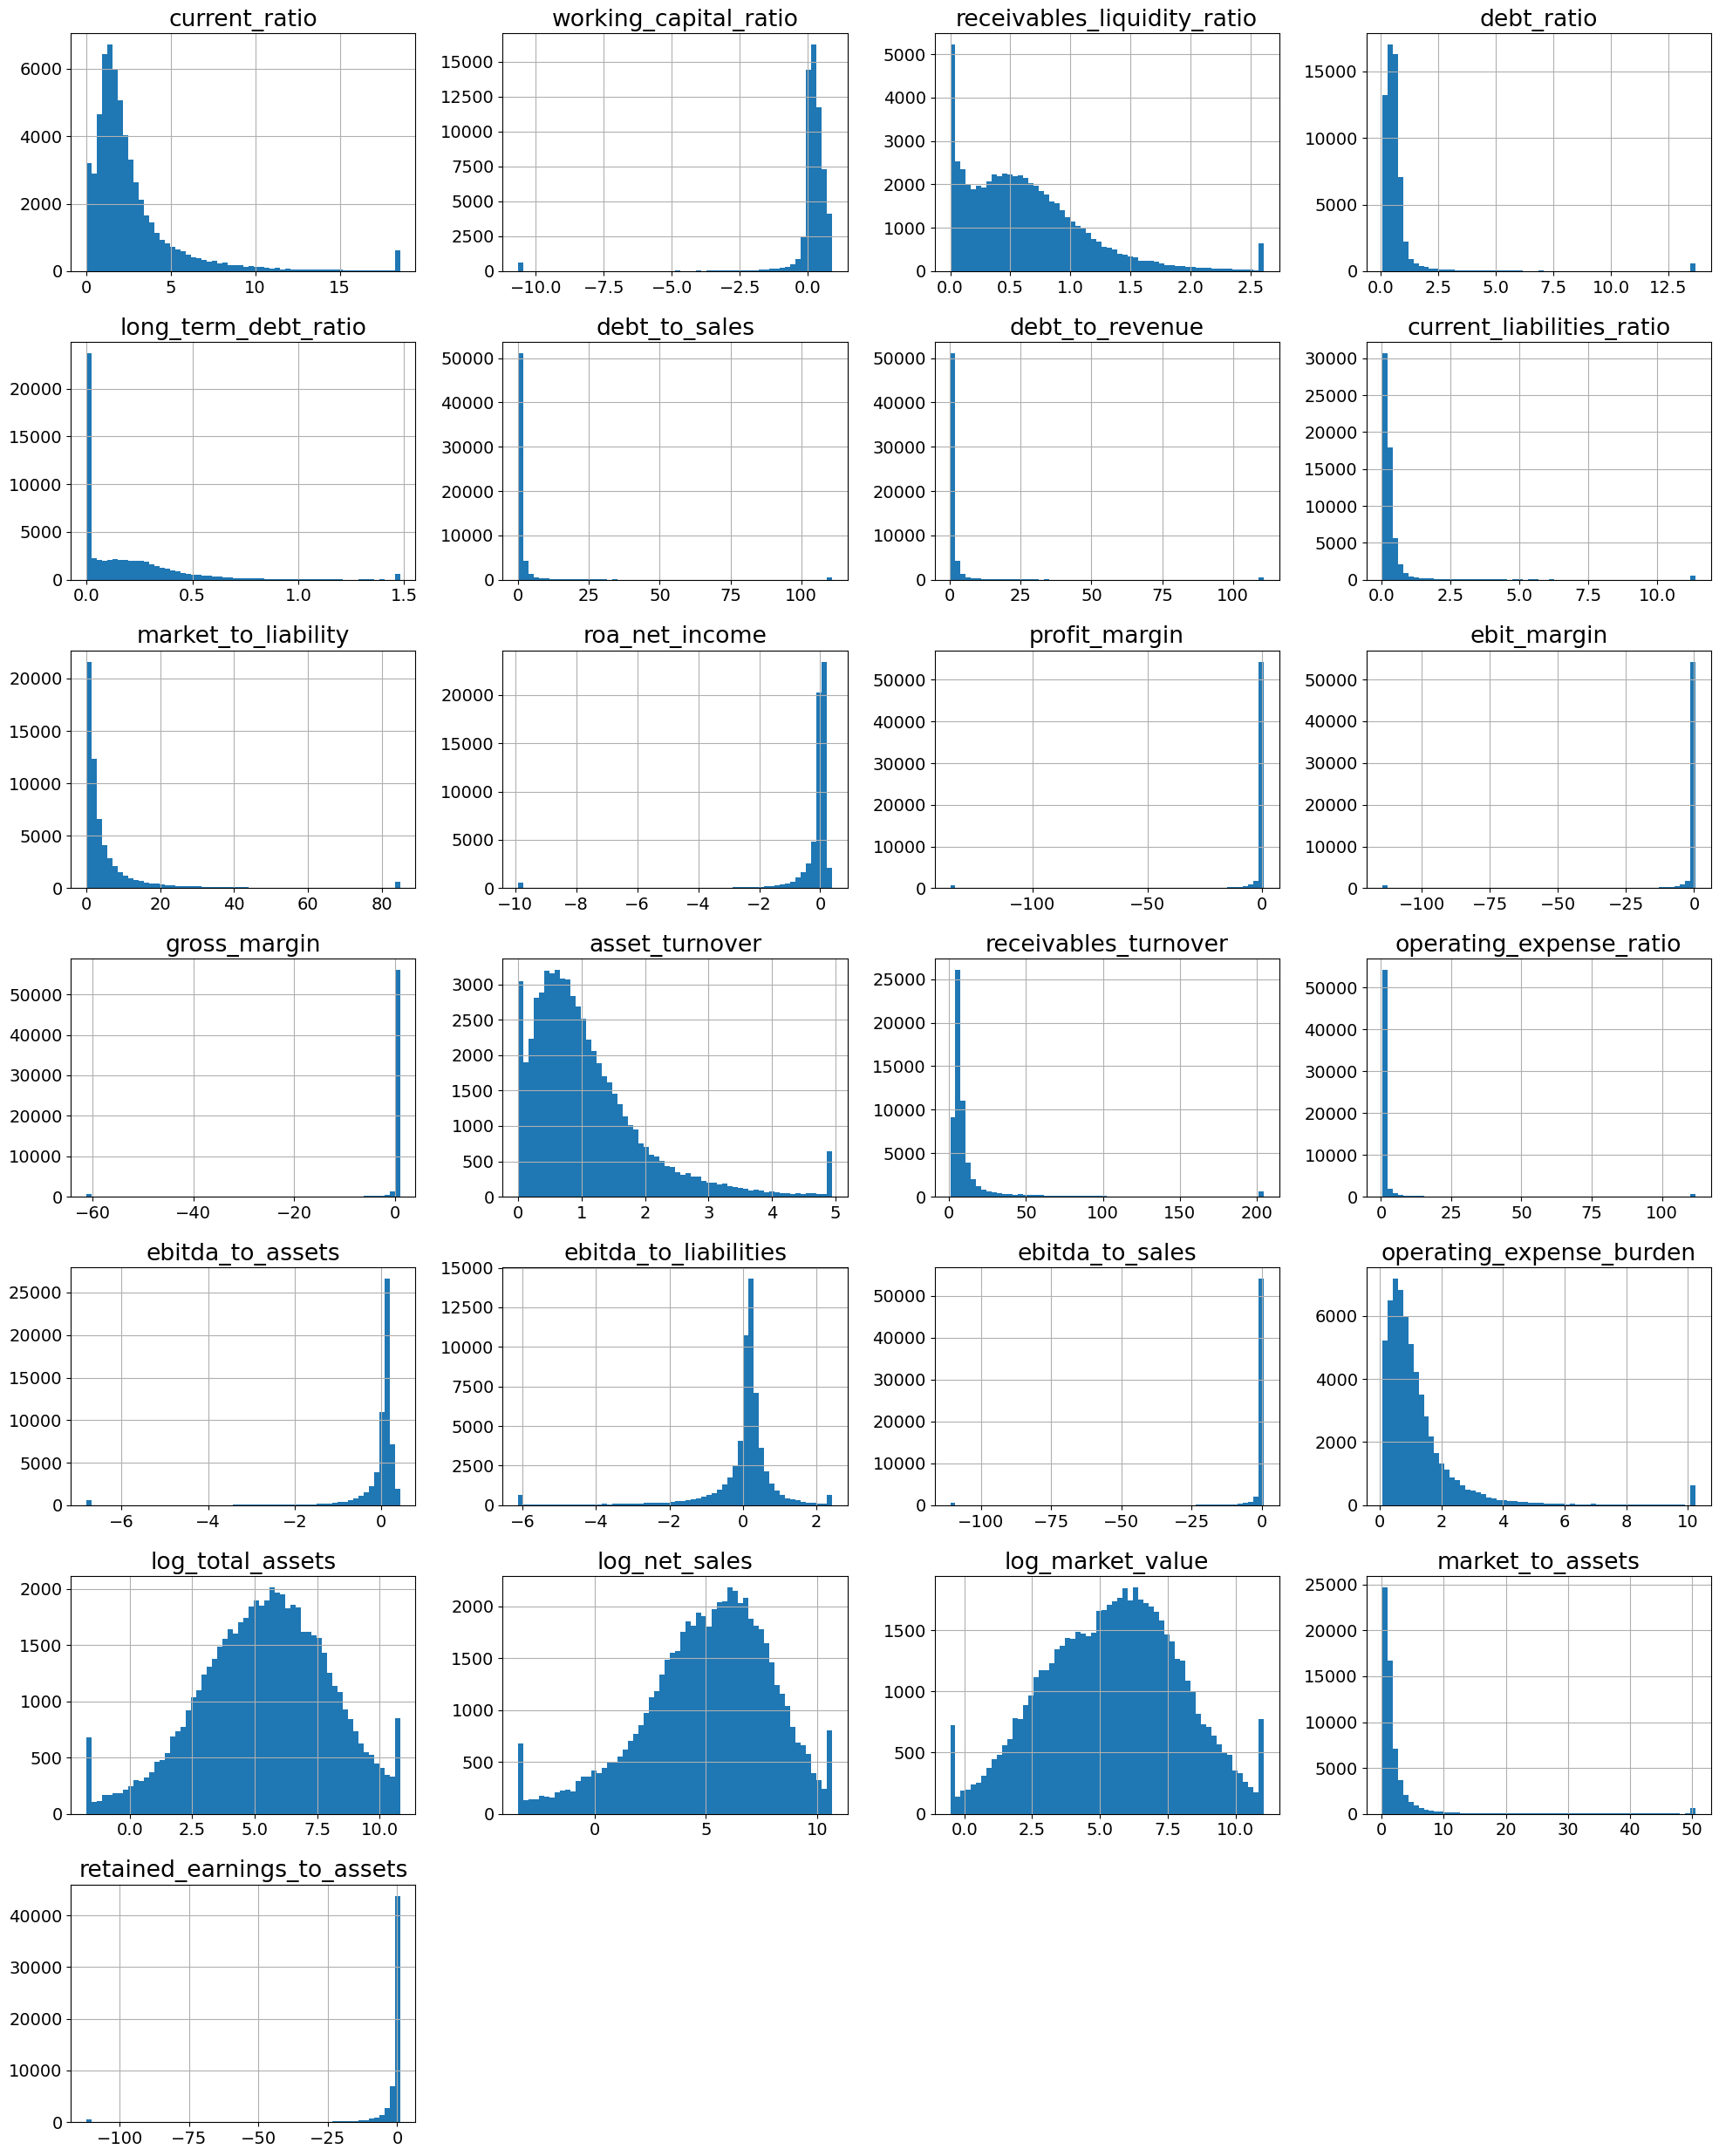

In [428]:
import numpy as np
import matplotlib.pyplot as plt
import math

# --------------------------------------------------
# 1. Select continuous features
# --------------------------------------------------
continuous_features = df_final_dataset.drop(
    columns=[
        "company_name", "regime", "year", "bankruptcy",
        "zero_inventory", "zero_accounts_receivables"
    ],
    errors="ignore"
)

continuous_features = continuous_features.select_dtypes(include=[np.number])
feature_cols = continuous_features.columns.tolist()

# --------------------------------------------------
# 2. Create winsorized dataset
# --------------------------------------------------

# --------------------------------------------------
#plotting
# --------------------------------------------------

df_winsorization[feature_cols].hist(figsize=(20,25), bins=60,layout=(7,4)) # bins is the thickness of the bars, .hist creates a histogram for each columnn in the dataframe
plt.tight_layout() # ensures no overlabbing between the figures 

plt.savefig("feature_distribution.pdf", bbox_inches="tight")



#### Selected distribtuion plots 

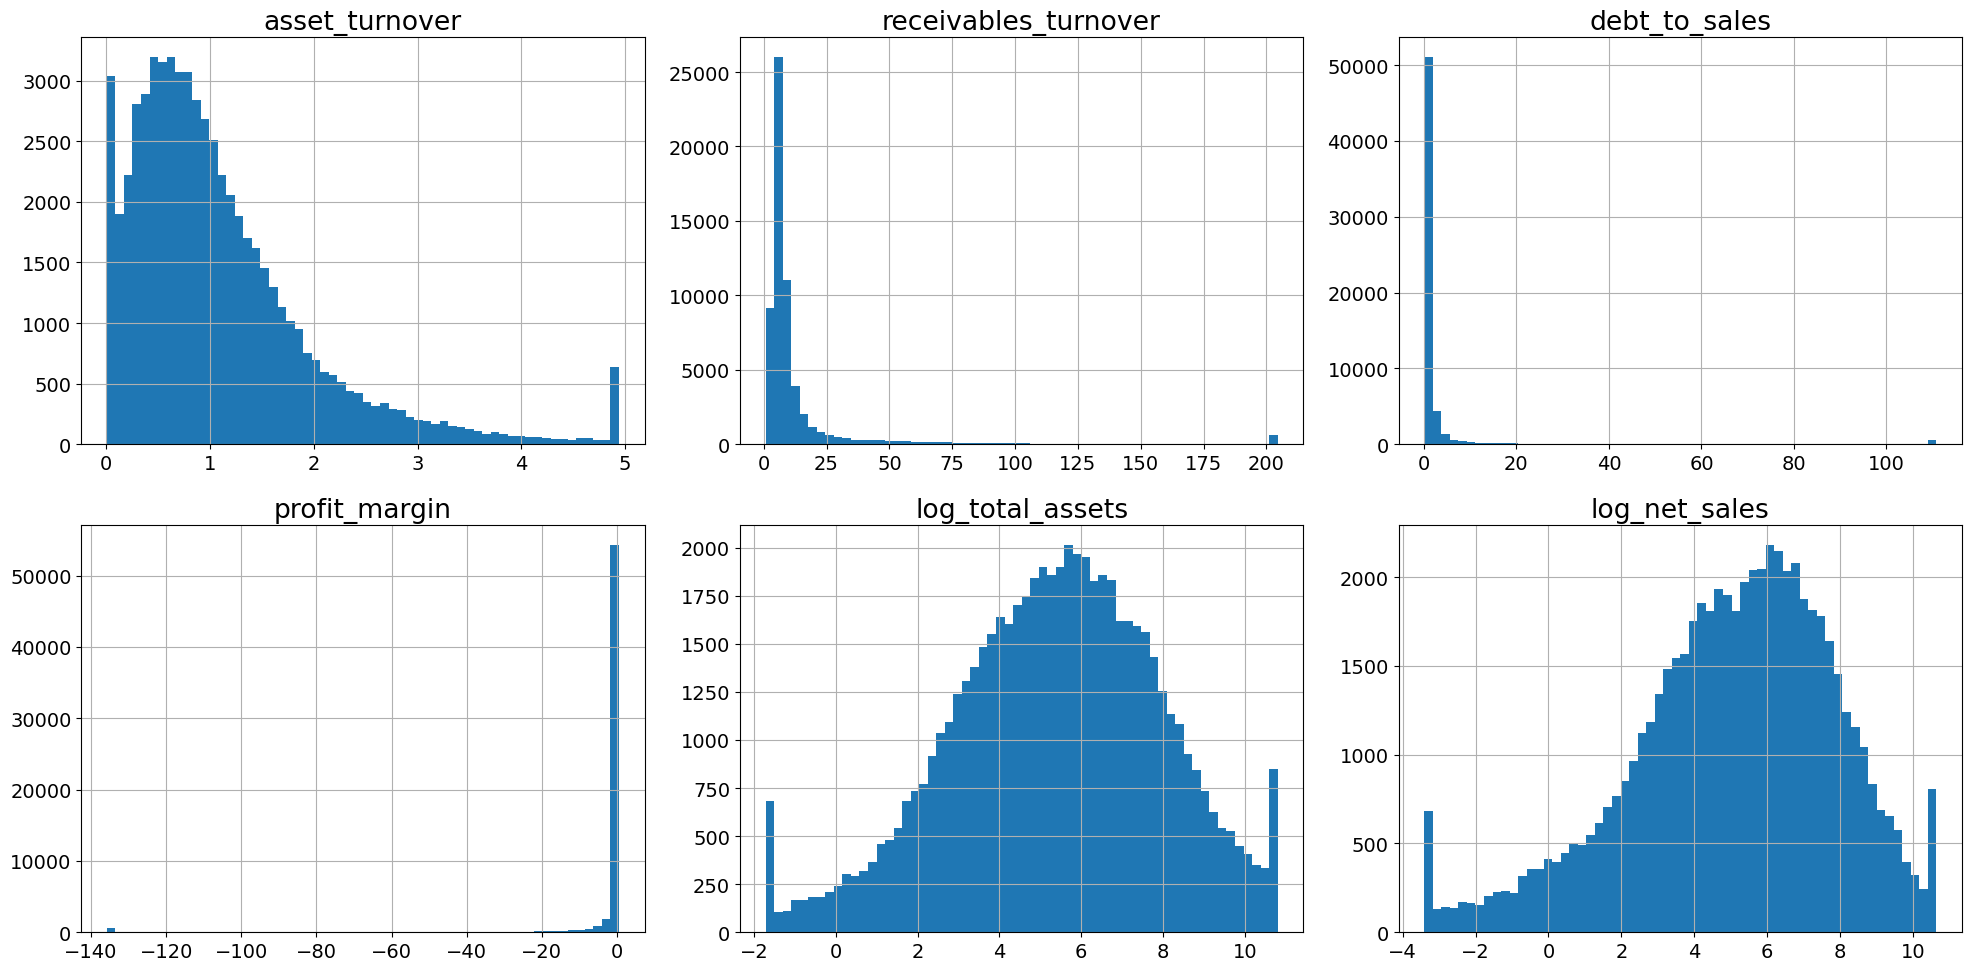

In [429]:
selected_distribution_features_plot = [
    "asset_turnover",
    "receivables_turnover",
    "debt_to_sales",
    "profit_margin",
    "log_total_assets",
    "log_net_sales"
]

df_winsorization[selected_distribution_features_plot].hist(figsize=(20,10), bins=60,layout=(2,3)) # bins is the thickness of the bars, .hist creates a histogram for each columnn in the dataframe
plt.tight_layout() # ensures no overlabbing between the figures 

plt.savefig("feature_distribution_selected.pdf", bbox_inches="tight")



np.float64(0.018162137825014996)

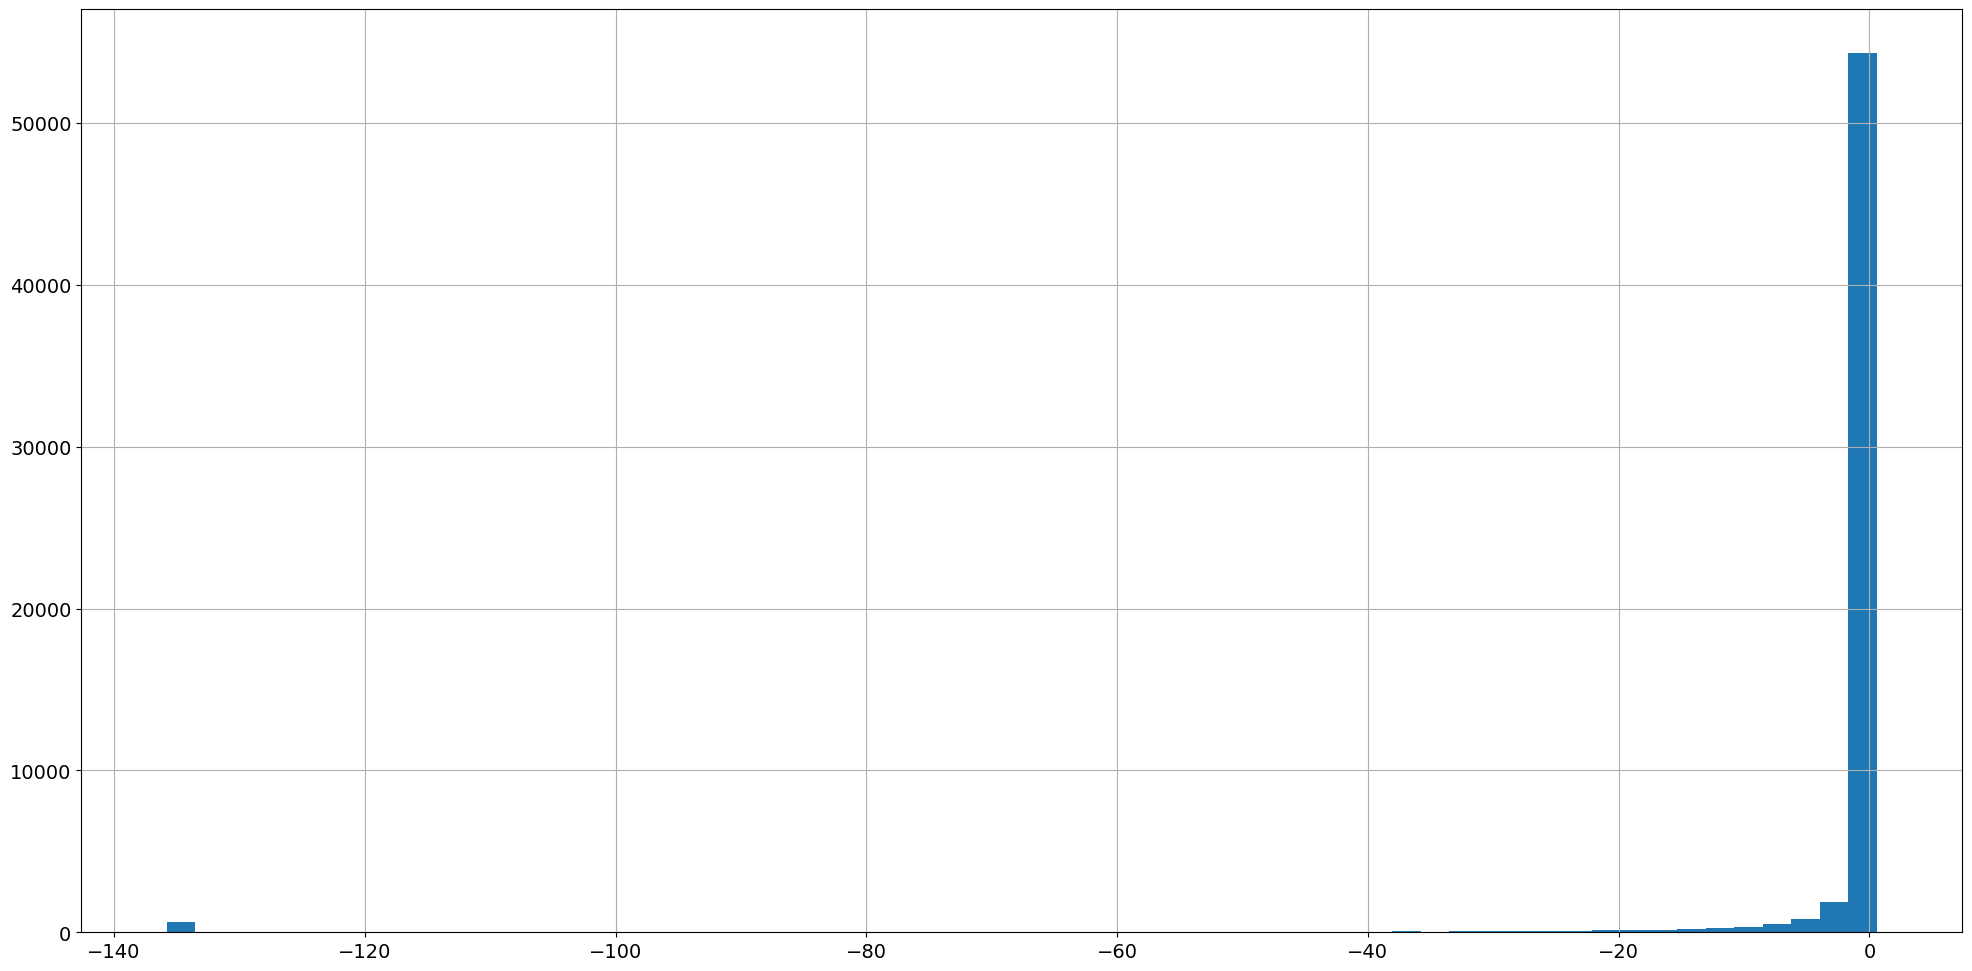

In [434]:
df_winsorization["profit_margin"].hist(figsize=(20,10), bins=60) # bins is the thickness of the bars, .hist creates a histogram for each columnn in the dataframe
plt.tight_layout() # ensures no overlabbing between the figures 

df_winsorization["profit_margin"].median()

## Correlation between features

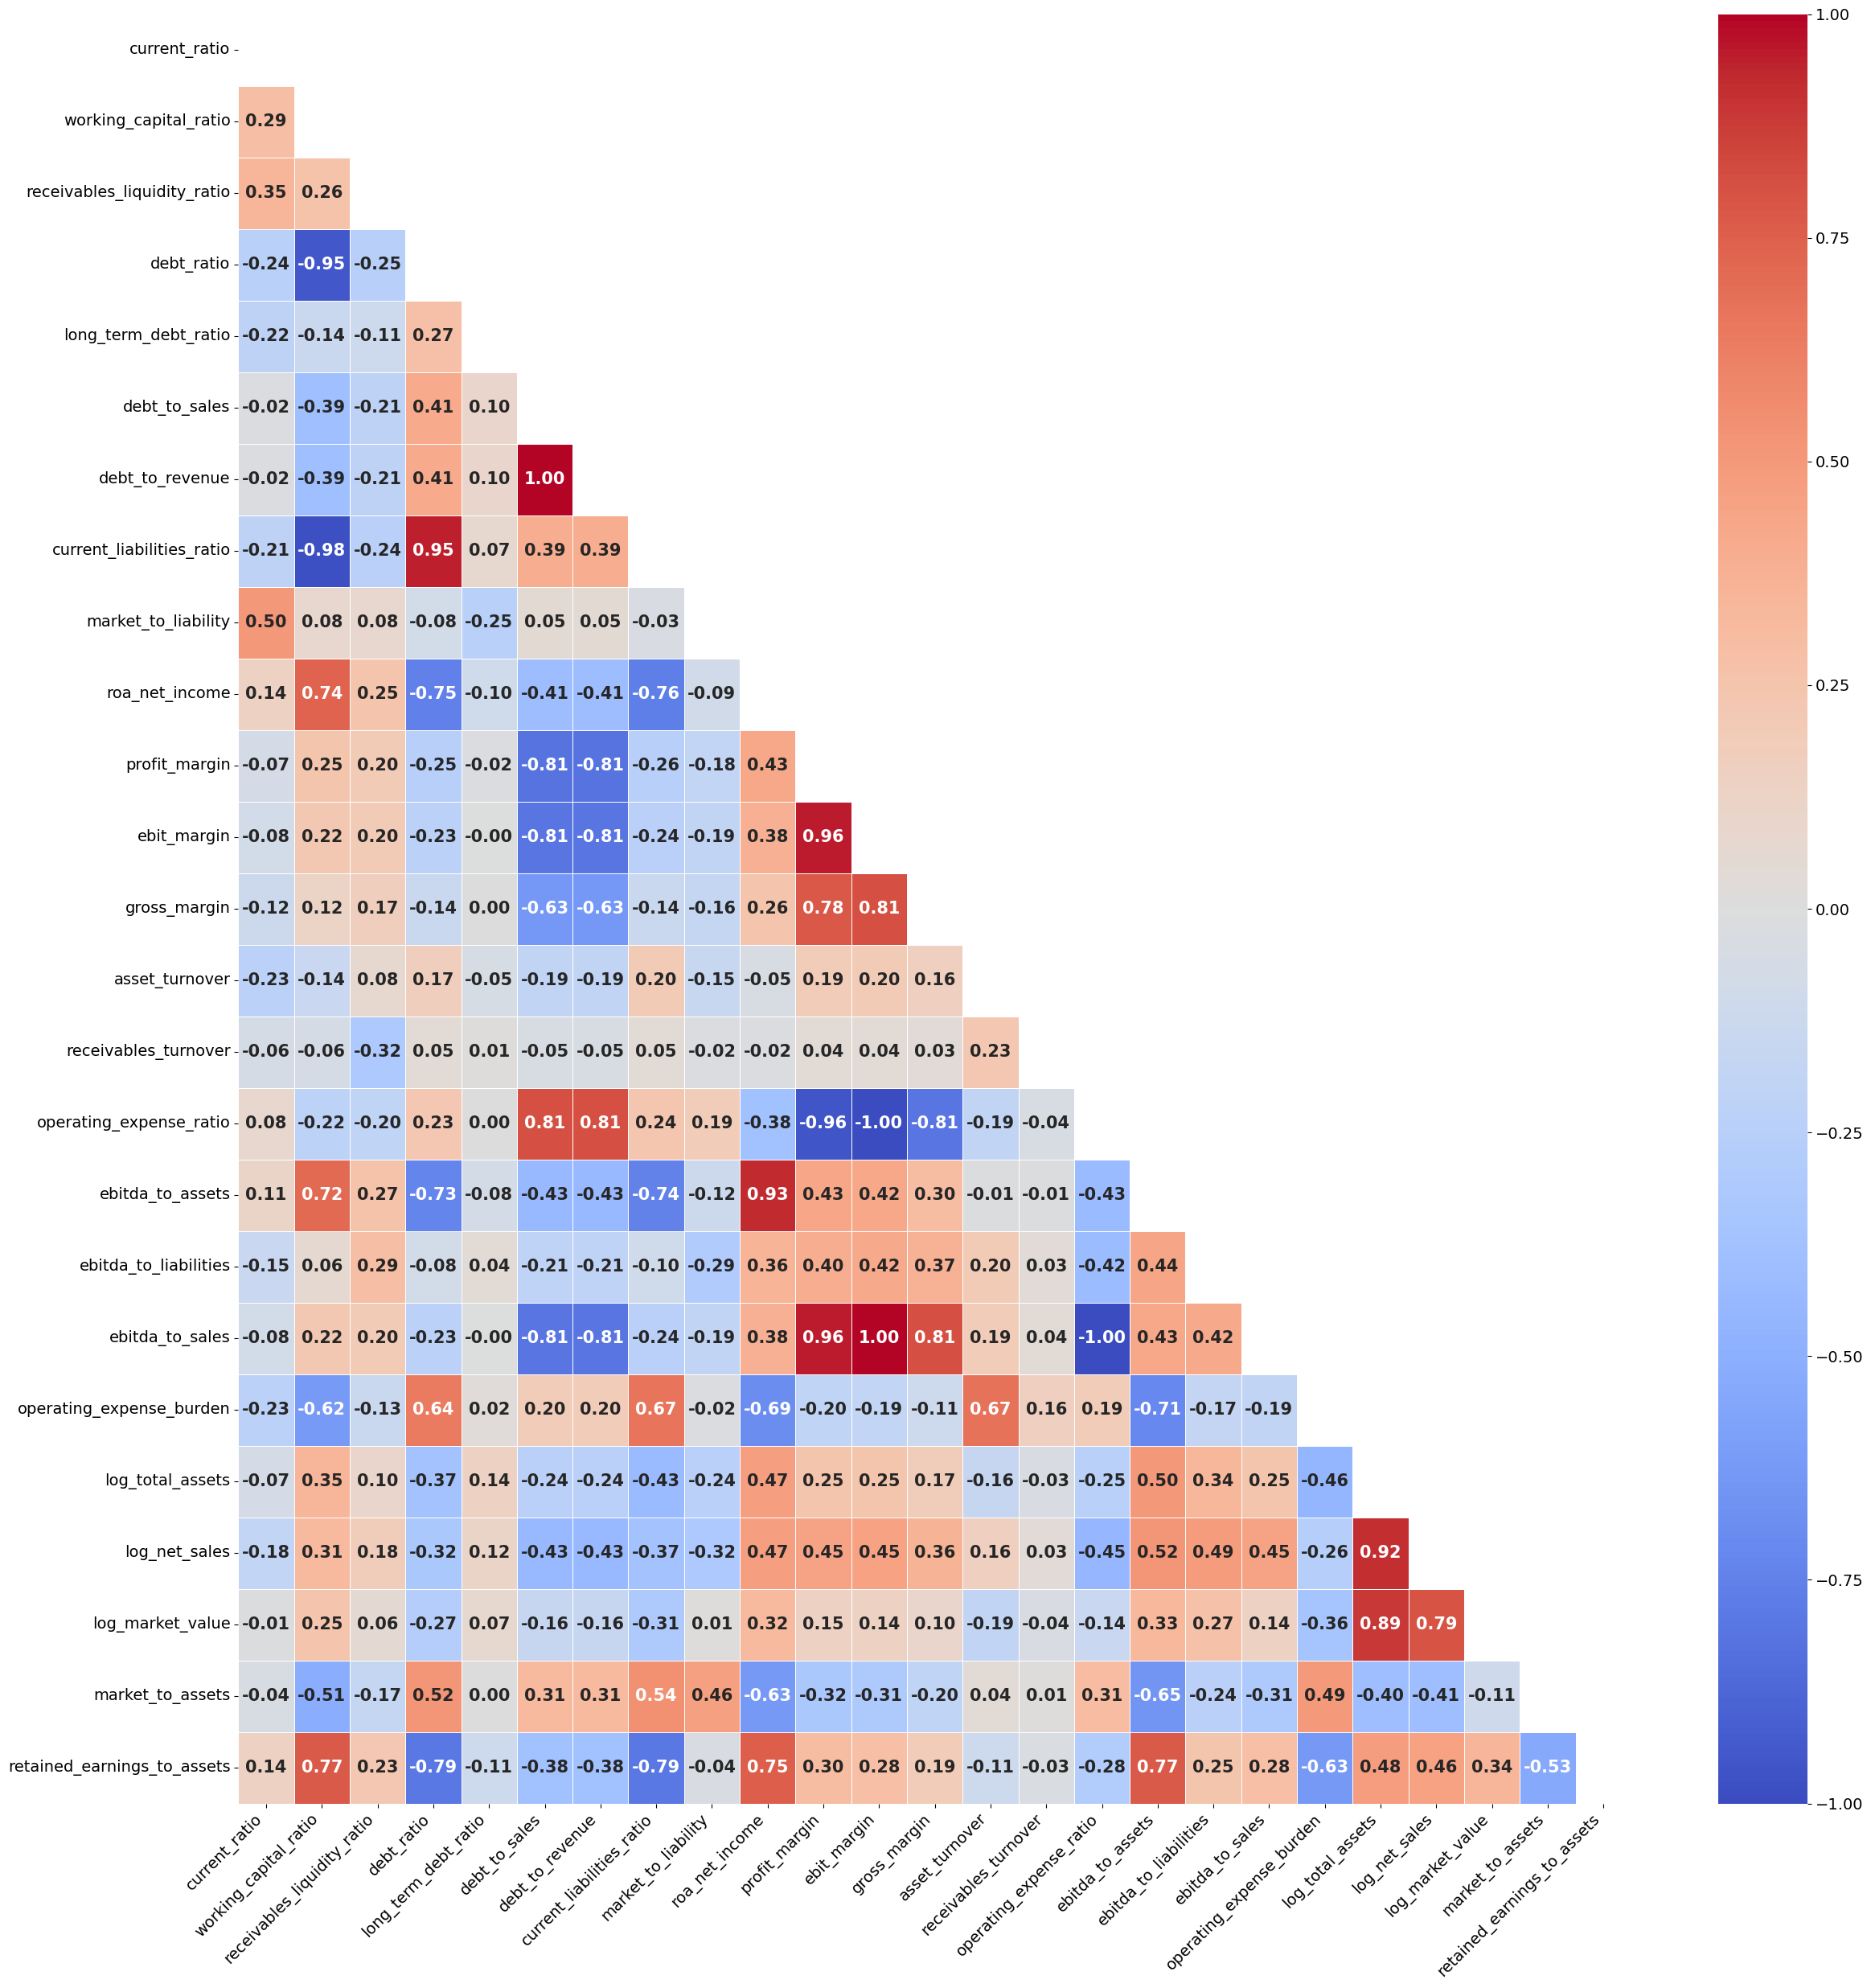

[('debt_to_revenue', 'debt_to_sales', np.float64(1.0))]

In [435]:
import seaborn as sns

continuous_features = df_final_dataset.drop(
    columns=[
        "company_name", "regime", "year", "bankruptcy",
        "zero_inventory", "zero_accounts_receivables"
    ],
    errors="ignore"
)

continuous_features = continuous_features.select_dtypes(include=[np.number])
feature_cols = continuous_features.columns.tolist()


data = df_winsorization[feature_cols]
correlation_matrix = data.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(25, 25))

sns.heatmap(correlation_matrix, 
annot=True, 
cmap='coolwarm', 
fmt=".2f", 
linewidths=0.5, 
mask=mask,
annot_kws={"size": 15,"fontweight":"bold"})
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("correlation_matrix_annotated.pdf", bbox_inches="tight")
plt.show()

perfect_positive_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if correlation_matrix.iloc[i, j] == 1.0:
            perfect_positive_pairs.append(
                (correlation_matrix.index[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j])
            )

perfect_positive_pairs


#### Dropping debt_revenue and ebita_sales

In [398]:
#df_winsorization = df_winsorization.drop(columns=["debt_to_revenue","ebitda_to_liabilities"])
df_winsorization.info()


<class 'pandas.core.frame.DataFrame'>
Index: 58587 entries, 4 to 11925
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   company_name                 58587 non-null  object 
 1   year                         58587 non-null  int64  
 2   bankruptcy                   58587 non-null  int64  
 3   regime                       58587 non-null  object 
 4   current_ratio                58587 non-null  float64
 5   working_capital_ratio        58587 non-null  float64
 6   receivables_liquidity_ratio  58587 non-null  float64
 7   debt_ratio                   58587 non-null  float64
 8   long_term_debt_ratio         58587 non-null  float64
 9   debt_to_sales                58587 non-null  float64
 10  current_liabilities_ratio    58587 non-null  float64
 11  market_to_liability          58587 non-null  float64
 12  roa_net_income               58587 non-null  float64
 13  profit_margin        

## Balance of the dataset 

In [399]:
print(df_winsorization.groupby("regime")["bankruptcy"].value_counts(dropna=False, normalize=True))
print(df_winsorization.groupby("regime")["bankruptcy"].value_counts(dropna=False))


regime       bankruptcy
crisis       0             0.989661
             1             0.010339
post_crisis  0             0.991204
             1             0.008796
pre_crisis   0             0.989339
             1             0.010661
Name: proportion, dtype: float64
regime       bankruptcy
crisis       0             11104
             1               116
post_crisis  0             26031
             1               231
pre_crisis   0             20880
             1               225
Name: count, dtype: int64
